In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load Online Retail dataset

file_path = "../data/raw/OnlineRetail.csv"

df = pd.read_csv(
    file_path,
    encoding="ISO-8859-1"
)

print(f"Dataset shape: {df.shape}")

Dataset shape: (541909, 8)


In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
InvoiceNo,541909,25900,573585,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
StockCode,541909,4070,85123A,2313,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description,540455,4223,WHITE HANGING HEART T-LIGHT HOLDER,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quantity,541909.0,NaN,NaN,NaN,9.55225,218.081158,-80995.0,1.0,3.0,10.0,80995.0
InvoiceDate,541909,23260,10/31/2011 14:41,1114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
UnitPrice,541909.0,NaN,NaN,NaN,4.611114,96.759853,-11062.06,1.25,2.08,4.13,38970.0
CustomerID,406829.0,NaN,NaN,NaN,15287.69057,1713.600303,12346.0,13953.0,15152.0,16791.0,18287.0
Country,541909,38,United Kingdom,495478,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Check missing values

missing = df.isnull().sum()

missing_percentage = (missing / len(df) * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
}).sort_values("Missing Values", ascending=False)

missing_summary

,Missing Values,Percentage
CustomerID,135080,24.93
Description,1454,0.27
StockCode,0,0.00
InvoiceNo,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
UnitPrice,0,0.00
Country,0,0.00


In [10]:
# Check duplicate rows

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 5268
Duplicate percentage: 0.97%


In [11]:
# Quantity statistics

df["Quantity"].describe()

count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [12]:
print("Negative quantity rows:", (df["Quantity"] < 0).sum())
print("Zero quantity rows:", (df["Quantity"] == 0).sum())
print("Positive quantity rows:", (df["Quantity"] > 0).sum())

Negative quantity rows: 10624
Zero quantity rows: 0
Positive quantity rows: 531285


In [13]:
# Unit price statistics

df["UnitPrice"].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

In [14]:
print("Zero-price transactions:", (df["UnitPrice"] == 0).sum())
print("Negative-price transactions:", (df["UnitPrice"] < 0).sum())

Zero-price transactions: 2515
Negative-price transactions: 2


In [15]:
# Check invoice numbers beginning with "C"

cancelled = df["InvoiceNo"].str.startswith("C")

print(f"Cancelled invoice rows: {cancelled.sum()}")
print(f"Percentage of dataset: {cancelled.mean() * 100:.2f}%")

Cancelled invoice rows: 9288
Percentage of dataset: 1.71%


In [16]:
df.loc[cancelled].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom


In [17]:
# Convert InvoiceDate to datetime

df["InvoiceDate_dt"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%m/%d/%Y %H:%M"
)

df[["InvoiceDate", "InvoiceDate_dt"]].head()

,InvoiceDate,InvoiceDate_dt
0,12/1/2010 8:26,2010-12-01 08:26:00
1,12/1/2010 8:26,2010-12-01 08:26:00
2,12/1/2010 8:26,2010-12-01 08:26:00
3,12/1/2010 8:26,2010-12-01 08:26:00
4,12/1/2010 8:26,2010-12-01 08:26:00


In [18]:
print("First transaction:", df["InvoiceDate_dt"].min())
print("Last transaction:", df["InvoiceDate_dt"].max())

First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [19]:
negative_qty = df["Quantity"] < 0
cancelled_invoice = df["InvoiceNo"].str.startswith("C")

print(
    "Negative quantity + cancelled invoice:",
    (negative_qty & cancelled_invoice).sum()
)

print(
    "Negative quantity + normal invoice:",
    (negative_qty & ~cancelled_invoice).sum()
)

Negative quantity + cancelled invoice: 9288
Negative quantity + normal invoice: 1336


In [20]:
# Create a copy of the raw dataset
df_clean = df.copy()

# Remove exact duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove transactions without CustomerID
df_clean = df_clean.dropna(subset=["CustomerID"])

# Remove transactions without product description
df_clean = df_clean.dropna(subset=["Description"])

# Keep only positive quantities
df_clean = df_clean[df_clean["Quantity"] > 0]

# Keep only positive unit prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Remove cancelled invoices
df_clean = df_clean[
    ~df_clean["InvoiceNo"].str.startswith("C")
]

print(f"Original rows: {len(df):,}")
print(f"Cleaned rows:  {len(df_clean):,}")
print(f"Rows removed:  {len(df) - len(df_clean):,}")

Original rows: 541,909
Cleaned rows:  392,692
Rows removed:  149,217


In [21]:
print("Missing CustomerID:", df_clean["CustomerID"].isna().sum())
print("Negative quantities:", (df_clean["Quantity"] < 0).sum())
print("Zero quantities:", (df_clean["Quantity"] == 0).sum())
print("Negative prices:", (df_clean["UnitPrice"] < 0).sum())
print("Zero prices:", (df_clean["UnitPrice"] == 0).sum())
print("Cancelled invoices:", df_clean["InvoiceNo"].str.startswith("C").sum())

Missing CustomerID: 0
Negative quantities: 0
Zero quantities: 0
Negative prices: 0
Zero prices: 0
Cancelled invoices: 0


Step 5 — Create transaction revenue

In [22]:
df_clean["Revenue"] = (
    df_clean["Quantity"] * df_clean["UnitPrice"]
)

In [23]:
df_clean[[
    "InvoiceNo",
    "StockCode",
    "Quantity",
    "UnitPrice",
    "Revenue",
    "CustomerID"
]].head(10)

,InvoiceNo,StockCode,Quantity,UnitPrice,Revenue,CustomerID
0,536365,85123A,6,2.55,15.30,17850.0
1,536365,71053,6,3.39,20.34,17850.0
2,536365,84406B,8,2.75,22.00,17850.0
3,536365,84029G,6,3.39,20.34,17850.0
4,536365,84029E,6,3.39,20.34,17850.0
5,536365,22752,2,7.65,15.30,17850.0
6,536365,21730,6,4.25,25.50,17850.0
7,536366,22633,6,1.85,11.10,17850.0
8,536366,22632,6,1.85,11.10,17850.0
9,536367,84879,32,1.69,54.08,13047.0


Step 6 - Convert CustomerID to an appropriate type

In [24]:
df_clean["CustomerID"] = (
    df_clean["CustomerID"]
    .astype(int)
    .astype(str)
)

In [25]:
df_clean["CustomerID"].head()

0    17850
1    17850
2    17850
3    17850
4    17850
Name: CustomerID, dtype: str

Step 7 — Clean up InvoiceDate

In [26]:
df_clean["InvoiceDate"] = df_clean["InvoiceDate_dt"]

df_clean = df_clean.drop(columns=["InvoiceDate_dt"])

In [27]:
df_clean.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID                str
Country                   str
Revenue               float64
dtype: object

Step 8 — Business sanity checks

In [28]:
# Total revenue

total_revenue = df_clean["Revenue"].sum()

print(f"Total Revenue: £{total_revenue:,.2f}")

Total Revenue: £8,887,208.89


In [29]:
# Unique customers

unique_customers = df_clean["CustomerID"].nunique()

print(f"Unique Customers: {unique_customers:,}")

Unique Customers: 4,338


In [30]:
# Unique completed orders

unique_orders = df_clean["InvoiceNo"].nunique()

print(f"Unique Orders: {unique_orders:,}")

Unique Orders: 18,532


In [31]:
print("First purchase:", df_clean["InvoiceDate"].min())
print("Last purchase:", df_clean["InvoiceDate"].max())

First purchase: 2010-12-01 08:26:00
Last purchase: 2011-12-09 12:50:00


In [32]:
# Final quality checks

print("Missing CustomerID:", df_clean["CustomerID"].isna().sum())
print("Missing InvoiceDate:", df_clean["InvoiceDate"].isna().sum())
print("Negative Quantity:", (df_clean["Quantity"] < 0).sum())
print("Zero Quantity:", (df_clean["Quantity"] == 0).sum())
print("Negative UnitPrice:", (df_clean["UnitPrice"] < 0).sum())
print("Zero UnitPrice:", (df_clean["UnitPrice"] == 0).sum())
print(
    "Cancelled Invoices:",
    df_clean["InvoiceNo"].str.startswith("C").sum()
)

Missing CustomerID: 0
Missing InvoiceDate: 0
Negative Quantity: 0
Zero Quantity: 0
Negative UnitPrice: 0
Zero UnitPrice: 0
Cancelled Invoices: 0


Step 9 — Save the cleaned dataset

In [33]:
# Save cleaned dataset

output_path = "../data/processed/online_retail_clean.csv"

df_clean.to_csv(output_path, index=False)

print(f"Cleaned dataset saved to: {output_path}")

Cleaned dataset saved to: ../data/processed/online_retail_clean.csv


Step 10 — Our first visualization

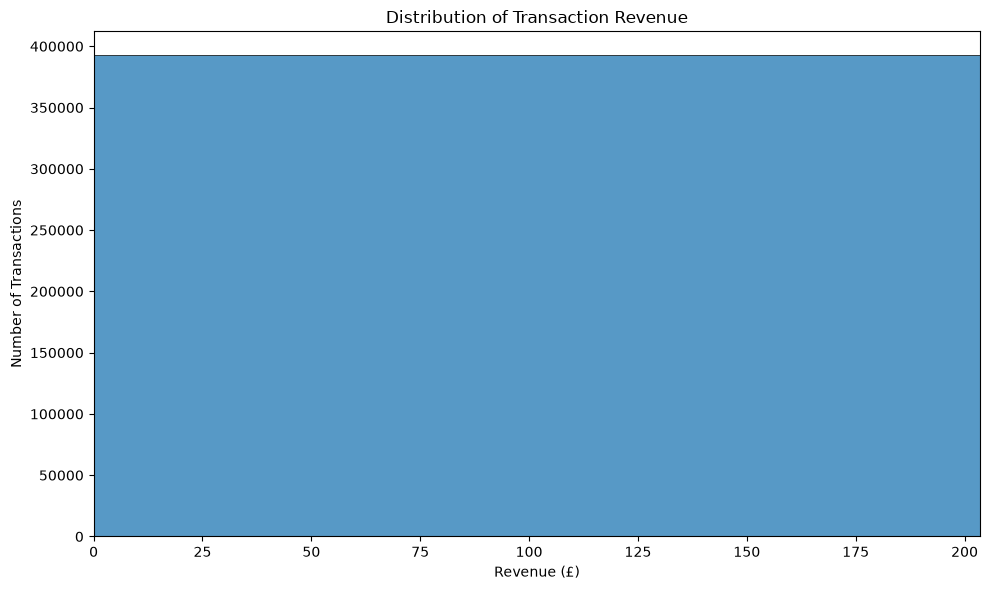

In [34]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["Revenue"],
    bins=100
)

plt.xlim(0, df_clean["Revenue"].quantile(0.99))

plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue (£)")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [35]:
# Create year-month feature

df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

monthly_revenue = (
    df_clean
    .groupby("YearMonth")["Revenue"]
    .sum()
)

monthly_revenue

YearMonth
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

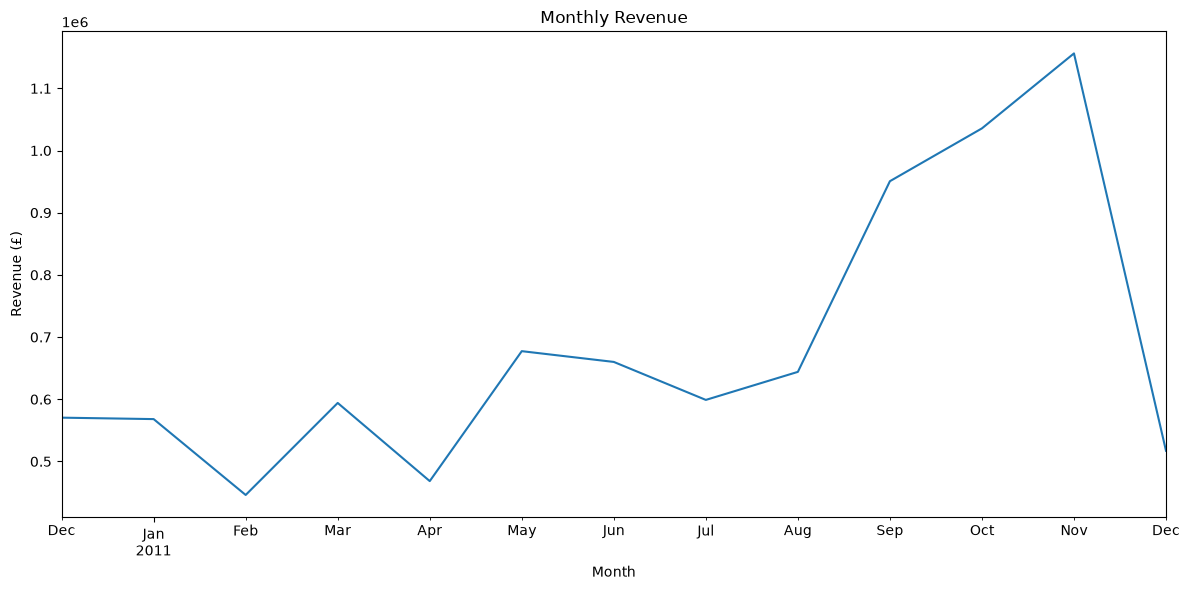

In [36]:
plt.figure(figsize=(12, 6))

monthly_revenue.plot()

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.tight_layout()
plt.show()

Step 11 — Build the Customer Feature Table

In [37]:
analysis_date = df_clean["InvoiceDate"].max() + pd.Timedelta(days=1)

print("Analysis date:", analysis_date)

Analysis date: 2011-12-10 12:50:00


In [38]:
rfm = (
    df_clean
    .groupby("CustomerID")
    .agg(
        Recency=(
            "InvoiceDate",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("Revenue", "sum")
    )
    .reset_index()
)

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [39]:
quantity_features = (
    df_clean
    .groupby("CustomerID")
    .agg(
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique")
    )
    .reset_index()
)

rfm = rfm.merge(
    quantity_features,
    on="CustomerID",
    how="left"
)

In [40]:
rfm["AverageOrderValue"] = (
    rfm["Monetary"] / rfm["Frequency"]
)

In [41]:
lifespan = (
    df_clean
    .groupby("CustomerID")["InvoiceDate"]
    .agg(
        FirstPurchase="min",
        LastPurchase="max"
    )
    .reset_index()
)

lifespan["CustomerLifespanDays"] = (
    lifespan["LastPurchase"] - lifespan["FirstPurchase"]
).dt.days

rfm = rfm.merge(
    lifespan[
        [
            "CustomerID",
            "FirstPurchase",
            "LastPurchase",
            "CustomerLifespanDays"
        ]
    ],
    on="CustomerID",
    how="left"
)

In [42]:
rfm["PurchaseFrequency"] = (
    rfm["Frequency"] /
    (rfm["CustomerLifespanDays"] + 1)
)

In [43]:
rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerLifespanDays,PurchaseFrequency
0,12346,326,1,77183.60,74215,1,77183.600000,2011-01-18 10:01:00,2011-01-18 10:01:00,0,1.000000
1,12347,2,7,4310.00,2458,103,615.714286,2010-12-07 14:57:00,2011-12-07 15:52:00,365,0.019126
2,12348,75,4,1797.24,2341,22,449.310000,2010-12-16 19:09:00,2011-09-25 13:13:00,282,0.014134
3,12349,19,1,1757.55,631,73,1757.550000,2011-11-21 09:51:00,2011-11-21 09:51:00,0,1.000000
4,12350,310,1,334.40,197,17,334.400000,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000
5,12352,36,8,2506.04,536,59,313.255000,2011-02-16 12:33:00,2011-11-03 14:37:00,260,0.030651
6,12353,204,1,89.00,20,4,89.000000,2011-05-19 17:47:00,2011-05-19 17:47:00,0,1.000000
7,12354,232,1,1079.40,530,58,1079.400000,2011-04-21 13:11:00,2011-04-21 13:11:00,0,1.000000
8,12355,214,1,459.40,240,13,459.400000,2011-05-09 13:49:00,2011-05-09 13:49:00,0,1.000000
9,12356,23,3,2811.43,1591,53,937.143333,2011-01-18 09:50:00,2011-11-17 08:40:00,302,0.009901


In [44]:
print("Customer feature table shape:", rfm.shape)

Customer feature table shape: (4338, 11)


In [45]:
rfm.describe().T

,count,mean,min,25%,50%,75%,max,std
Recency,4338.0,92.536422,1.0,18.0,51.0,142.0,374.0,100.014169
Frequency,4338.0,4.272015,1.0,1.0,2.0,5.0,209.0,7.697998
Monetary,4338.0,2048.688081,3.75,306.4825,668.57,1660.5975,280206.02,8985.23022
TotalQuantity,4338.0,1187.644537,1.0,159.0,378.0,989.75,196915.0,5043.619654
UniqueProducts,4338.0,61.501153,1.0,16.0,35.0,77.0,1787.0,85.366768
AverageOrderValue,4338.0,417.645735,3.45,177.867083,291.94,428.280625,84236.25,1796.511343
FirstPurchase,4338,2011-04-30 17:06:50.857538,2010-12-01 08:26:00,2011-01-17 11:13:15,2011-04-05 09:52:30,2011-08-19 10:11:30,2011-12-09 12:16:00,NaN
LastPurchase,4338,2011-09-08 11:38:59.045643,2010-12-01 09:53:00,2011-07-20 19:18:00,2011-10-20 10:40:30,2011-11-22 11:05:45,2011-12-09 12:50:00,NaN
CustomerLifespanDays,4338.0,130.448594,0.0,0.0,92.5,251.75,373.0,132.039554
PurchaseFrequency,4338.0,0.406695,0.005464,0.020234,0.04609,1.0,17.0,0.571636


Step 12 — Analyze the customer distributions

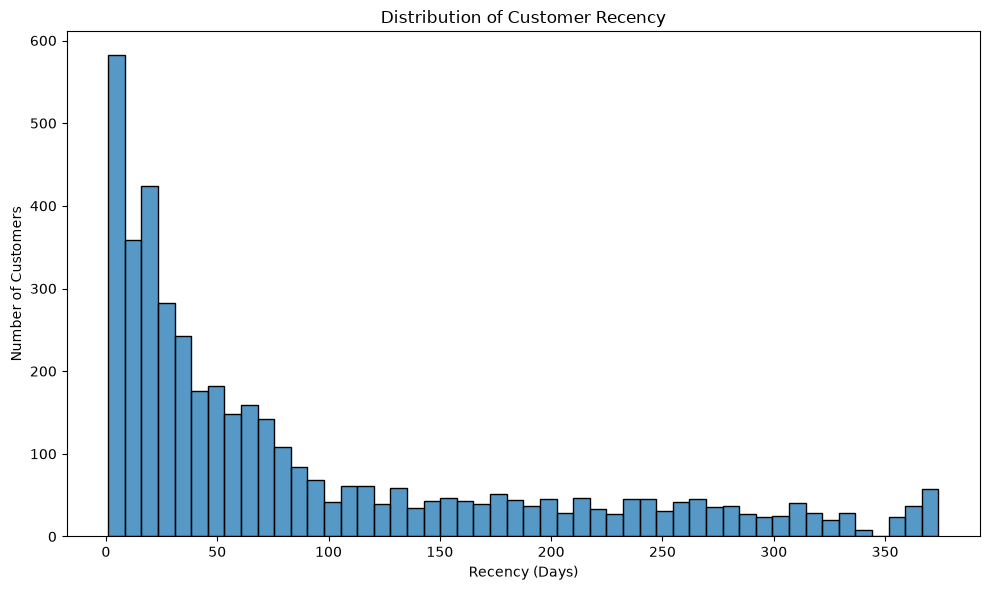

In [46]:
plt.figure(figsize=(10, 6))

sns.histplot(
    rfm["Recency"],
    bins=50
)

plt.title("Distribution of Customer Recency")
plt.xlabel("Recency (Days)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

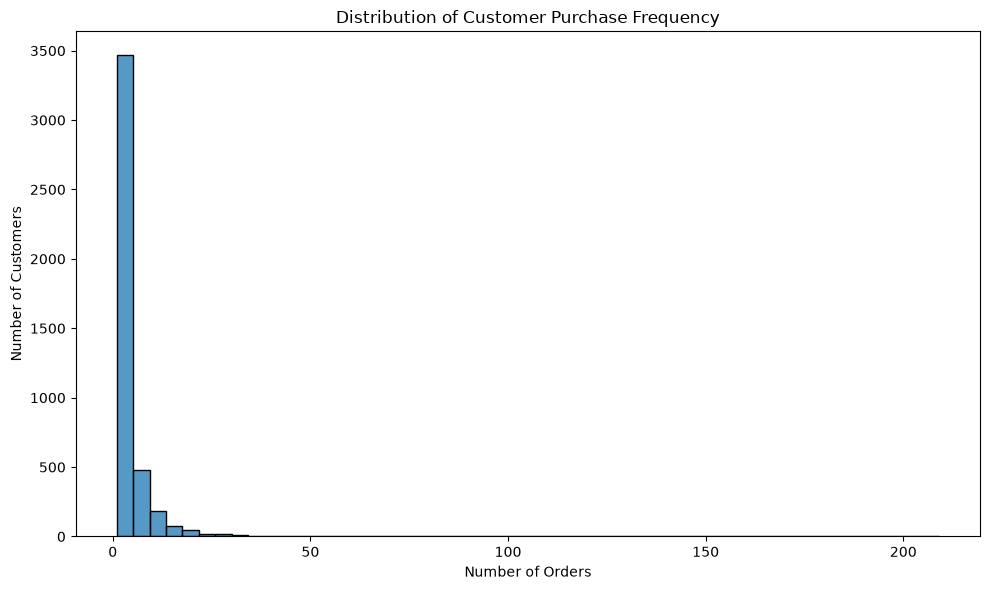

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    rfm["Frequency"],
    bins=50
)

plt.title("Distribution of Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

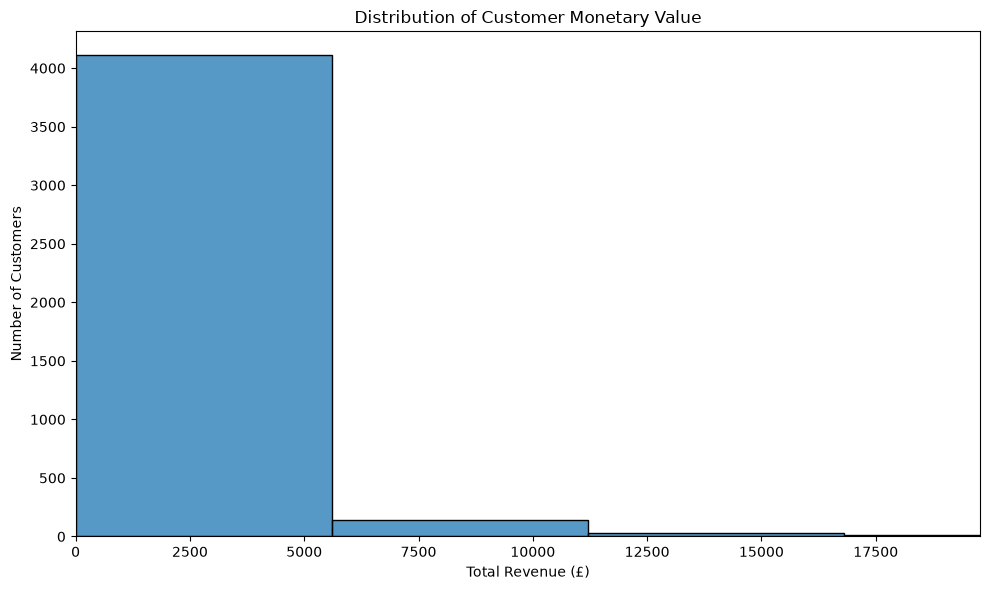

In [48]:
plt.figure(figsize=(10, 6))

sns.histplot(
    rfm["Monetary"],
    bins=50
)

plt.title("Distribution of Customer Monetary Value")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Number of Customers")

plt.xlim(0, rfm["Monetary"].quantile(0.99))

plt.tight_layout()
plt.show()

Step 13 — Examine the extreme customers

In [49]:
rfm.nlargest(
    10,
    "Monetary"
)[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AverageOrderValue"
]]

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue
1689,14646,2,73,280206.02,196915,700,3838.438630
4201,18102,1,60,259657.30,64124,150,4327.621667
3728,17450,8,46,194390.79,69973,124,4225.886739
3008,16446,1,2,168472.50,80997,3,84236.250000
1879,14911,1,201,143711.17,80240,1787,714.980945
55,12415,24,21,124914.53,77374,444,5948.310952
1333,14156,10,55,117210.08,57768,714,2131.092364
3771,17511,3,31,91062.38,64549,453,2937.496129
2702,16029,39,63,80850.84,40108,44,1283.346667
0,12346,326,1,77183.60,74215,1,77183.600000


In [50]:
rfm.nlargest(
    10,
    "Frequency"
)[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue"
]]

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
326,12748,1,209,33053.19,158.149234
1879,14911,1,201,143711.17,714.980945
4010,17841,2,124,40519.84,326.772903
562,13089,3,97,58762.08,605.794639
1661,14606,1,93,12076.15,129.851075
2176,15311,1,91,60632.75,666.293956
481,12971,4,86,11189.91,130.115233
1689,14646,2,73,280206.02,3838.438630
2702,16029,39,63,80850.84,1283.346667
795,13408,2,62,28117.04,453.500645


In [51]:
rfm.nsmallest(
    10,
    "Recency"
)[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary"
]]

,CustomerID,Recency,Frequency,Monetary
61,12423,1,8,1859.31
71,12433,1,7,13375.87
137,12518,1,5,2056.89
144,12526,1,3,1316.66
258,12662,1,11,3849.78
271,12680,1,4,862.81
297,12713,1,1,848.55
326,12748,1,209,33053.19
471,12955,1,11,4757.16
489,12985,1,2,1239.38


Step 14 — Check how many customers are one-time buyers

In [52]:
one_time_customers = (rfm["Frequency"] == 1).sum()

print(f"One-time customers: {one_time_customers:,}")
print(
    f"Percentage of customers: "
    f"{one_time_customers / len(rfm) * 100:.2f}%"
)

One-time customers: 1,493
Percentage of customers: 34.42%


In [53]:
repeat_customers = (rfm["Frequency"] > 1).sum()

print(f"Repeat customers: {repeat_customers:,}")
print(
    f"Percentage of customers: "
    f"{repeat_customers / len(rfm) * 100:.2f}%"
)

Repeat customers: 2,845
Percentage of customers: 65.58%


Step 15 — Check the customer counts

In [54]:
one_time_customers = (rfm["Frequency"] == 1).sum()
repeat_customers = (rfm["Frequency"] > 1).sum()

print(f"One-time customers: {one_time_customers:,}")
print(f"One-time percentage: {one_time_customers / len(rfm) * 100:.2f}%")
print()

print(f"Repeat customers: {repeat_customers:,}")
print(f"Repeat percentage: {repeat_customers / len(rfm) * 100:.2f}%")

One-time customers: 1,493
One-time percentage: 34.42%

Repeat customers: 2,845
Repeat percentage: 65.58%


Step 16 — Inspect the highest-value customers

In [55]:
top_monetary = rfm.nlargest(
    10,
    "Monetary"
)[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "AverageOrderValue"
]]

top_monetary

,CustomerID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,AverageOrderValue
1689,14646,2,73,280206.02,196915,700,3838.438630
4201,18102,1,60,259657.30,64124,150,4327.621667
3728,17450,8,46,194390.79,69973,124,4225.886739
3008,16446,1,2,168472.50,80997,3,84236.250000
1879,14911,1,201,143711.17,80240,1787,714.980945
55,12415,24,21,124914.53,77374,444,5948.310952
1333,14156,10,55,117210.08,57768,714,2131.092364
3771,17511,3,31,91062.38,64549,453,2937.496129
2702,16029,39,63,80850.84,40108,44,1283.346667
0,12346,326,1,77183.60,74215,1,77183.600000


In [56]:
top_frequency = rfm.nlargest(
    10,
    "Frequency"
)[[
    "CustomerID",
    "Recency",
    "Frequency",
    "Monetary",
    "AverageOrderValue"
]]

top_frequency

,CustomerID,Recency,Frequency,Monetary,AverageOrderValue
326,12748,1,209,33053.19,158.149234
1879,14911,1,201,143711.17,714.980945
4010,17841,2,124,40519.84,326.772903
562,13089,3,97,58762.08,605.794639
1661,14606,1,93,12076.15,129.851075
2176,15311,1,91,60632.75,666.293956
481,12971,4,86,11189.91,130.115233
1689,14646,2,73,280206.02,3838.438630
2702,16029,39,63,80850.84,1283.346667
795,13408,2,62,28117.04,453.500645


Step 17 — Fix the behavioral frequency metric

In [57]:
active_months = (
    df_clean
    .assign(
        YearMonth=df_clean["InvoiceDate"].dt.to_period("M")
    )
    .groupby("CustomerID")["YearMonth"]
    .nunique()
    .reset_index(name="ActiveMonths")
)

rfm = rfm.merge(
    active_months,
    on="CustomerID",
    how="left"
)

In [58]:
rfm["OrdersPerActiveMonth"] = (
    rfm["Frequency"] / rfm["ActiveMonths"]
)

In [59]:
rfm[[
    "CustomerID",
    "Frequency",
    "ActiveMonths",
    "OrdersPerActiveMonth"
]].head(20)

,CustomerID,Frequency,ActiveMonths,OrdersPerActiveMonth
0,12346,1,1,1.00
1,12347,7,7,1.00
2,12348,4,4,1.00
3,12349,1,1,1.00
4,12350,1,1,1.00
5,12352,8,4,2.00
6,12353,1,1,1.00
7,12354,1,1,1.00
8,12355,1,1,1.00
9,12356,3,3,1.00


Step 18 — Look at the new behavioral feature

In [60]:
rfm["OrdersPerActiveMonth"].describe()

count    4338.000000
mean        1.225594
std         0.765747
min         1.000000
25%         1.000000
50%         1.000000
75%         1.250000
max        34.000000
Name: OrdersPerActiveMonth, dtype: float64

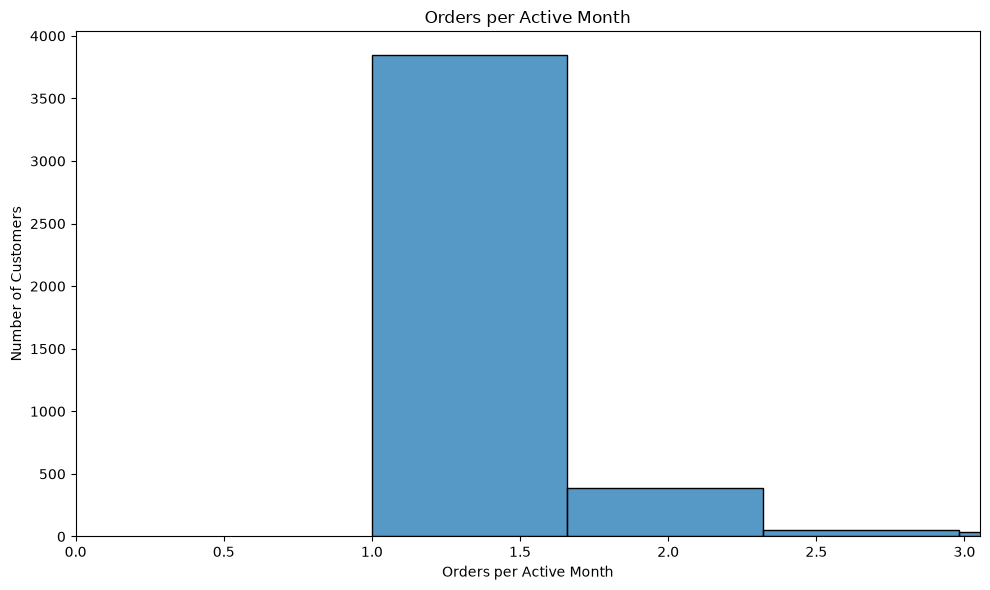

In [61]:
plt.figure(figsize=(10, 6))

sns.histplot(
    rfm["OrdersPerActiveMonth"],
    bins=50
)

plt.title("Orders per Active Month")
plt.xlabel("Orders per Active Month")
plt.ylabel("Number of Customers")

plt.xlim(
    0,
    rfm["OrdersPerActiveMonth"].quantile(0.99)
)

plt.tight_layout()
plt.show()

Step 19 — Prepare RFM variables

In [62]:
rfm_features = rfm[[
    "Recency",
    "Frequency",
    "Monetary"
]].copy()

rfm_features.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


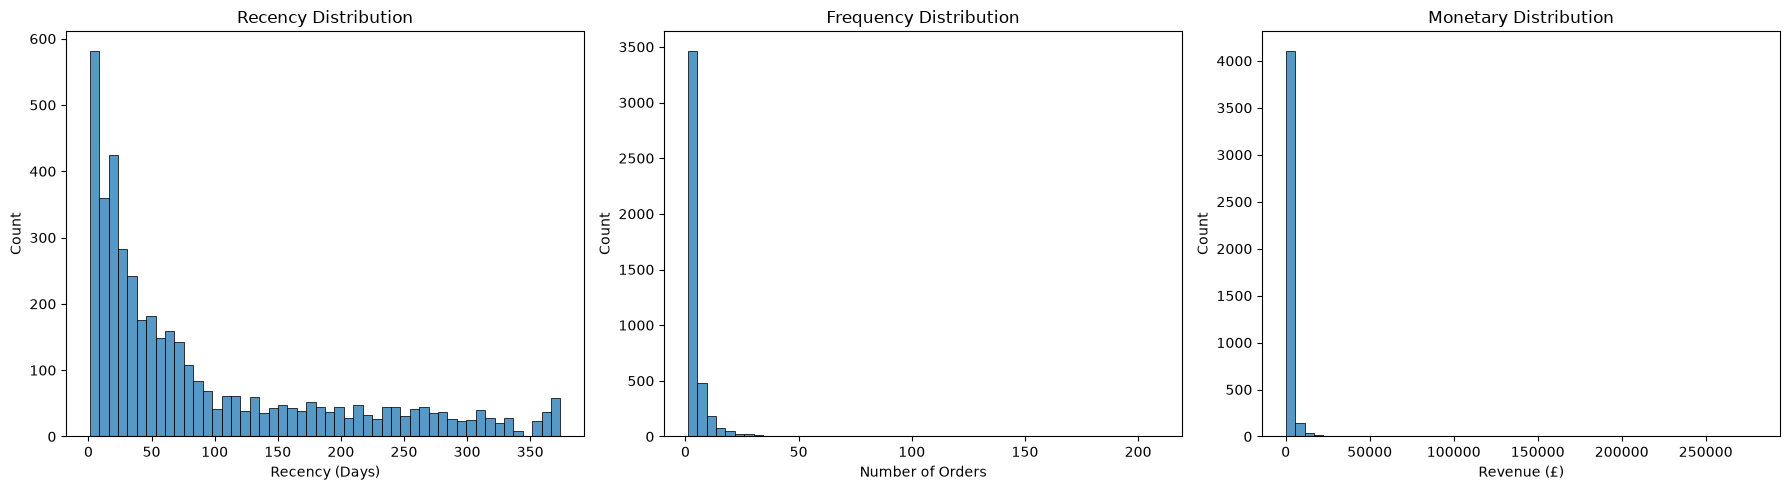

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm["Recency"], bins=50, ax=axes[0])
axes[0].set_title("Recency Distribution")
axes[0].set_xlabel("Recency (Days)")

sns.histplot(rfm["Frequency"], bins=50, ax=axes[1])
axes[1].set_title("Frequency Distribution")
axes[1].set_xlabel("Number of Orders")

sns.histplot(rfm["Monetary"], bins=50, ax=axes[2])
axes[2].set_title("Monetary Distribution")
axes[2].set_xlabel("Revenue (£)")

plt.tight_layout()
plt.show()

In [64]:
import os

processed_dir = "../data/processed"
os.makedirs(processed_dir, exist_ok=True)

df_clean.to_csv(
    f"{processed_dir}/online_retail_clean.csv",
    index=False
)

print("Cleaned dataset saved successfully.")
print(f"Rows: {len(df_clean):,}")

Cleaned dataset saved successfully.
Rows: 392,692
